In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

from postprocessing import topics_subtopics, topics_subtopics_flatten

In [ ]:
class ReviewEvaluator:
    def __init__(self, all_topics, all_sentiments):
        """
        Инициализация оценщика
        
        Args:
            all_topics (list): Все возможные темы
            all_sentiments (list): Все возможные тональности
        """
        self.all_topics = all_topics
        self.all_sentiments = all_sentiments
        
    def prepare_topic_data(self, data):
        """
        Преобразует данные в бинарные векторы для multi-label классификации тем
        """
        y_binary = np.zeros((len(data), len(self.all_topics)), dtype=int)
        
        for i, review in enumerate(data):
            for topic_dict in review:
                topic = topic_dict['topic']
                if topic in self.all_topics:
                    idx = self.all_topics.index(topic)
                    y_binary[i, idx] = 1
                    
        return y_binary
    
    def prepare_sentiment_data(self, true_data, pred_data):
        """
        Собирает пары (тема, тональность) для правильно предсказанных тем
        """
        true_sentiments = []
        pred_sentiments = []
        
        for true_review, pred_review in zip(true_data, pred_data):
            # Преобразуем в множества для сравнения
            true_topics_set = set(item['topic'] for item in true_review)
            pred_topics_set = set(item['topic'] for item in pred_review)
            
            # Находим пересечение - правильно предсказанные темы
            correct_topics = true_topics_set & pred_topics_set
            
            for topic in correct_topics:
                # Находим соответствующие тональности
                true_sent = next(item['sentiment'] for item in true_review 
                               if item['topic'] == topic)
                pred_sent = next(item['sentiment'] for item in pred_review 
                               if item['topic'] == topic)
                
                true_sentiments.append(true_sent)
                pred_sentiments.append(pred_sent)
                
        return true_sentiments, pred_sentiments
    
    def evaluate(self, true_data, pred_data, model_name="Model"):
        """
        Полная оценка модели
        """
        print(f"=== Оценка модели: {model_name} ===")
        
        # 1. Оценка тем (Multi-label F1 Micro)
        y_true_topics = self.prepare_topic_data(true_data)
        y_pred_topics = self.prepare_topic_data(pred_data)
        
        topic_f1_micro = f1_score(y_true_topics, y_pred_topics, average='micro', zero_division=0)
        topic_f1_macro = f1_score(y_true_topics, y_pred_topics, average='macro', zero_division=0)
        
        print(f"\n--- Оценка определения тем ---")
        print(f"F1 Micro: {topic_f1_micro:.4f}")
        print(f"F1 Macro: {topic_f1_macro:.4f}")
        
        # Детальный отчет по темам
        print(f"\nДетальный отчет по темам:")
        topic_report = classification_report(
            y_true_topics, y_pred_topics, 
            target_names=self.all_topics, 
            zero_division=0
        )
        print(topic_report)
        
        # 2. Оценка тональности (Accuracy)
        true_sentiments, pred_sentiments = self.prepare_sentiment_data(true_data, pred_data)
        
        if true_sentiments:  # Если есть правильно предсказанные темы
            sentiment_accuracy = accuracy_score(true_sentiments, pred_sentiments)
            print(f"\n--- Оценка анализа тональности ---")
            print(f"Accuracy (только для правильных тем): {sentiment_accuracy:.4f}")
            print(f"Количество примеров для оценки: {len(true_sentiments)}")
            
            # 3. Confusion Matrix для тональности
            self.plot_confusion_matrix(true_sentiments, pred_sentiments, model_name)
            
            # Детальный отчет по тональности
            print(f"\nДетальный отчет по тональности:")
            sentiment_report = classification_report(
                true_sentiments, pred_sentiments, 
                target_names=self.all_sentiments,
                zero_division=0
            )
            print(sentiment_report)
        else:
            print("\nНет правильно предсказанных тем для оценки тональности")
        
        return {
            'topic_f1_micro': topic_f1_micro,
            'topic_f1_macro': topic_f1_macro,
            'sentiment_accuracy': sentiment_accuracy if true_sentiments else 0
        }
    
    def plot_confusion_matrix(self, true_sentiments, pred_sentiments, model_name):
        """
        Строит и отображает confusion matrix для тональности
        """
        cm = confusion_matrix(true_sentiments, pred_sentiments, labels=self.all_sentiments)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.all_sentiments,
                   yticklabels=self.all_sentiments)
        plt.title(f'Confusion Matrix - {model_name}\n(только для правильных тем)')
        plt.xlabel('Предсказанная тональность')
        plt.ylabel('Истинная тональность')
        plt.tight_layout()
        plt.show()
        
        # Выводим normalized confusion matrix
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                   xticklabels=self.all_sentiments,
                   yticklabels=self.all_sentiments)
        plt.title(f'Normalized Confusion Matrix - {model_name}\n(только для правильных тем)')
        plt.xlabel('Предсказанная тональность')
        plt.ylabel('Истинная тональность')
        plt.tight_layout()
        plt.show()
        
        return cm

In [15]:
# Пример данных
all_topics = topics_subtopics_flatten
all_sentiments = ['positive', 'negative', 'neutral']

# Истинные данные (разметка)
true_data = [
    [
        {"topic": "Кредитная карта", "sentiment": "negative"},
        {"topic": "Страховые и услуги", "sentiment": "neutral"}
    ],
    [
        {"topic": "Ипотека", "sentiment": "positive"}
    ],
    [
        {"topic": "Мобильный банк", "sentiment": "positive"},
        {"topic": "Вклады", "sentiment": "negative"}
    ]
]

# Предсказания модели
pred_data = [
    [
        {"topic": "Кредитная карта", "sentiment": "negative"},  # правильно
        {"topic": "Страховые и услуги", "sentiment": "positive"} # тема правильная, тональность нет
    ],
    [
        {"topic": "Ипотека", "sentiment": "positive"}  # все правильно
    ],
    [
        {"topic": "Мобильный банк", "sentiment": "positive"},  # все правильно
        {"topic": "Кредитная карта", "sentiment": "negative"},  # лишняя тема
        {"topic": "Вклады", "sentiment": "negative"}
    ]
]

# Создаем оценщик и запускаем оценку
evaluator = ReviewEvaluator(all_topics, all_sentiments)
metrics = evaluator.evaluate(true_data, pred_data, "Пример модели")

print(f"\nИтоговые метрики: {metrics}")

=== Оценка модели: Пример модели ===

--- Оценка определения тем ---
F1 Micro: 1.0000
F1 Macro: 0.0290

Детальный отчет по темам:
                                                    precision    recall  f1-score   support

                              Офисное обслуживание       0.00      0.00      0.00         0
                                         Банкоматы       0.00      0.00      0.00         0
                        Дистанционное обслуживание       0.00      0.00      0.00         0
                                   Дебетовые карты       0.00      0.00      0.00         0
                                 Денежные переводы       0.00      0.00      0.00         0
                                    Карта UnionPay       0.00      0.00      0.00         0
                       Умная дебетовая карта «Мир»       0.00      0.00      0.00         0
                     Премиальная карта Mir Supreme       0.00      0.00      0.00         0
Карта для автолюбителей «Газпромбанк—Газп

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report, multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

In [9]:
class ReviewEvaluator:
    def __init__(self, all_topics, all_sentiments):
        self.all_topics = all_topics
        self.all_sentiments = all_sentiments
        
    def prepare_topic_data(self, data):
        """Преобразует данные в бинарные векторы для multi-label классификации тем"""
        y_binary = np.zeros((len(data), len(self.all_topics)), dtype=int)
        
        for i, review in enumerate(data):
            for topic_dict in review:
                topic = topic_dict['topic']
                if topic in self.all_topics:
                    idx = self.all_topics.index(topic)
                    y_binary[i, idx] = 1
                    
        return y_binary
    
    def prepare_sentiment_data(self, true_data, pred_data):
        """Собирает пары (тема, тональность) для правильно предсказанных тем"""
        true_sentiments = []
        pred_sentiments = []
        
        for true_review, pred_review in zip(true_data, pred_data):
            true_topics_set = set(item['topic'] for item in true_review)
            pred_topics_set = set(item['topic'] for item in pred_review)
            
            correct_topics = true_topics_set & pred_topics_set
            
            for topic in correct_topics:
                true_sent = next(item['sentiment'] for item in true_review 
                               if item['topic'] == topic)
                pred_sent = next(item['sentiment'] for item in pred_review 
                               if item['topic'] == topic)
                
                true_sentiments.append(true_sent)
                pred_sentiments.append(pred_sent)
                
        return true_sentiments, pred_sentiments
    
    def plot_topic_confusion_matrices(self, y_true, y_pred):
        """Строит confusion matrix для каждой темы отдельно"""
        mcm = multilabel_confusion_matrix(y_true, y_pred)
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.ravel()
        
        for i, (matrix, topic) in enumerate(zip(mcm, self.all_topics)):
            if i < len(axes):
                sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                           xticklabels=['False', 'True'],
                           yticklabels=['False', 'True'])
                axes[i].set_title(f'Topic: {topic}\nTN={matrix[0,0]}, FP={matrix[0,1]}\nFN={matrix[1,0]}, TP={matrix[1,1]}')
                axes[i].set_xlabel('Predicted')
                axes[i].set_ylabel('Actual')
        
        # Скрываем лишние subplots
        for i in range(len(self.all_topics), len(axes)):
            axes[i].set_visible(False)
            
        plt.tight_layout()
        plt.show()
        
        return mcm
    
    def plot_topic_correlation_matrix(self, y_true, y_pred):
        """Матрица корреляции между предсказаниями тем"""
        n_topics = len(self.all_topics)
        correlation_matrix = np.zeros((n_topics, n_topics))
        
        for i in range(n_topics):
            for j in range(n_topics):
                # Считаем, как часто тема i предсказывалась, когда должна была быть тема j
                mask_true = y_true[:, j] == 1
                if np.sum(mask_true) > 0:
                    correlation_matrix[i, j] = np.mean(y_pred[mask_true, i])
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
                   xticklabels=self.all_topics, yticklabels=self.all_topics)
        plt.title('Topic Prediction Correlation Matrix\n(How often topic X is predicted when topic Y is true)')
        plt.xlabel('True Topics')
        plt.ylabel('Predicted Topics')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        return correlation_matrix
    
    def plot_topic_accuracy_by_class(self, y_true, y_pred):
        """Точность по каждой теме отдельно"""
        topic_metrics = {}
        
        for i, topic in enumerate(self.all_topics):
            true_pos = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 1))
            false_pos = np.sum((y_true[:, i] == 0) & (y_pred[:, i] == 1))
            false_neg = np.sum((y_true[:, i] == 1) & (y_pred[:, i] == 0))
            true_neg = np.sum((y_true[:, i] == 0) & (y_pred[:, i] == 0))
            
            precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
            recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            topic_metrics[topic] = {
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'support': np.sum(y_true[:, i])
            }
        
        # Визуализация
        metrics_df = pd.DataFrame(topic_metrics).T
        metrics_df[['precision', 'recall', 'f1']].plot(kind='bar', figsize=(12, 6))
        plt.title('Topic-wise Metrics')
        plt.xlabel('Topics')
        plt.ylabel('Score')
        plt.xticks(rotation=45)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
        return topic_metrics
    
    def evaluate(self, true_data, pred_data, model_name="Model"):
        """Полная оценка модели"""
        print(f"=== Оценка модели: {model_name} ===")
        
        # 1. Оценка тем (Multi-label F1 Micro)
        y_true_topics = self.prepare_topic_data(true_data)
        y_pred_topics = self.prepare_topic_data(pred_data)
        
        topic_f1_micro = f1_score(y_true_topics, y_pred_topics, average='micro', zero_division=0)
        topic_f1_macro = f1_score(y_true_topics, y_pred_topics, average='macro', zero_division=0)
        topic_f1_weighted = f1_score(y_true_topics, y_pred_topics, average='weighted', zero_division=0)
        
        print(f"\n--- Оценка определения тем ---")
        print(f"F1 Micro: {topic_f1_micro:.4f}")
        print(f"F1 Macro: {topic_f1_macro:.4f}")
        print(f"F1 Weighted: {topic_f1_weighted:.4f}")
        
        # Confusion Matrix для тем
        print(f"\n--- Confusion Matrix для тем ---")
        self.plot_topic_confusion_matrices(y_true_topics, y_pred_topics)
        
        # Матрица корреляции тем
        print(f"\n--- Корреляция предсказаний тем ---")
        self.plot_topic_correlation_matrix(y_true_topics, y_pred_topics)
        
        # Метрики по каждой теме
        print(f"\n--- Метрики по каждой теме ---")
        topic_metrics = self.plot_topic_accuracy_by_class(y_true_topics, y_pred_topics)
        
        # Детальный отчет по темам
        print(f"\nДетальный отчет по темам:")
        topic_report = classification_report(
            y_true_topics, y_pred_topics, 
            target_names=self.all_topics, 
            zero_division=0
        )
        print(topic_report)
        
        # 2. Оценка тональности
        true_sentiments, pred_sentiments = self.prepare_sentiment_data(true_data, pred_data)
        
        if true_sentiments:
            sentiment_accuracy = accuracy_score(true_sentiments, pred_sentiments)
            print(f"\n--- Оценка анализа тональности ---")
            print(f"Accuracy (только для правильных тем): {sentiment_accuracy:.4f}")
            print(f"Количество примеров для оценки: {len(true_sentiments)}")
            
            # Confusion Matrix для тональности
            self.plot_sentiment_confusion_matrix(true_sentiments, pred_sentiments, model_name)
            
            # Детальный отчет по тональности
            print(f"\nДетальный отчет по тональности:")
            sentiment_report = classification_report(
                true_sentiments, pred_sentiments, 
                target_names=self.all_sentiments,
                zero_division=0
            )
            print(sentiment_report)
        else:
            print("\nНет правильно предсказанных тем для оценки тональности")
            sentiment_accuracy = 0
        
        return {
            'topic_f1_micro': topic_f1_micro,
            'topic_f1_macro': topic_f1_macro,
            'topic_f1_weighted': topic_f1_weighted,
            'sentiment_accuracy': sentiment_accuracy,
            'topic_metrics': topic_metrics
        }
    
    def plot_sentiment_confusion_matrix(self, true_sentiments, pred_sentiments, model_name):
        """Строит confusion matrix для тональности"""
        cm = confusion_matrix(true_sentiments, pred_sentiments, labels=self.all_sentiments)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.all_sentiments,
                   yticklabels=self.all_sentiments)
        plt.title(f'Confusion Matrix - {model_name}\n(только для правильных тем)')
        plt.xlabel('Предсказанная тональность')
        plt.ylabel('Истинная тональность')
        plt.tight_layout()
        plt.show()

=== Оценка модели: Пример модели ===

--- Оценка определения тем ---
F1 Micro: 0.7143
F1 Macro: 0.6267
F1 Weighted: 0.6571

--- Confusion Matrix для тем ---


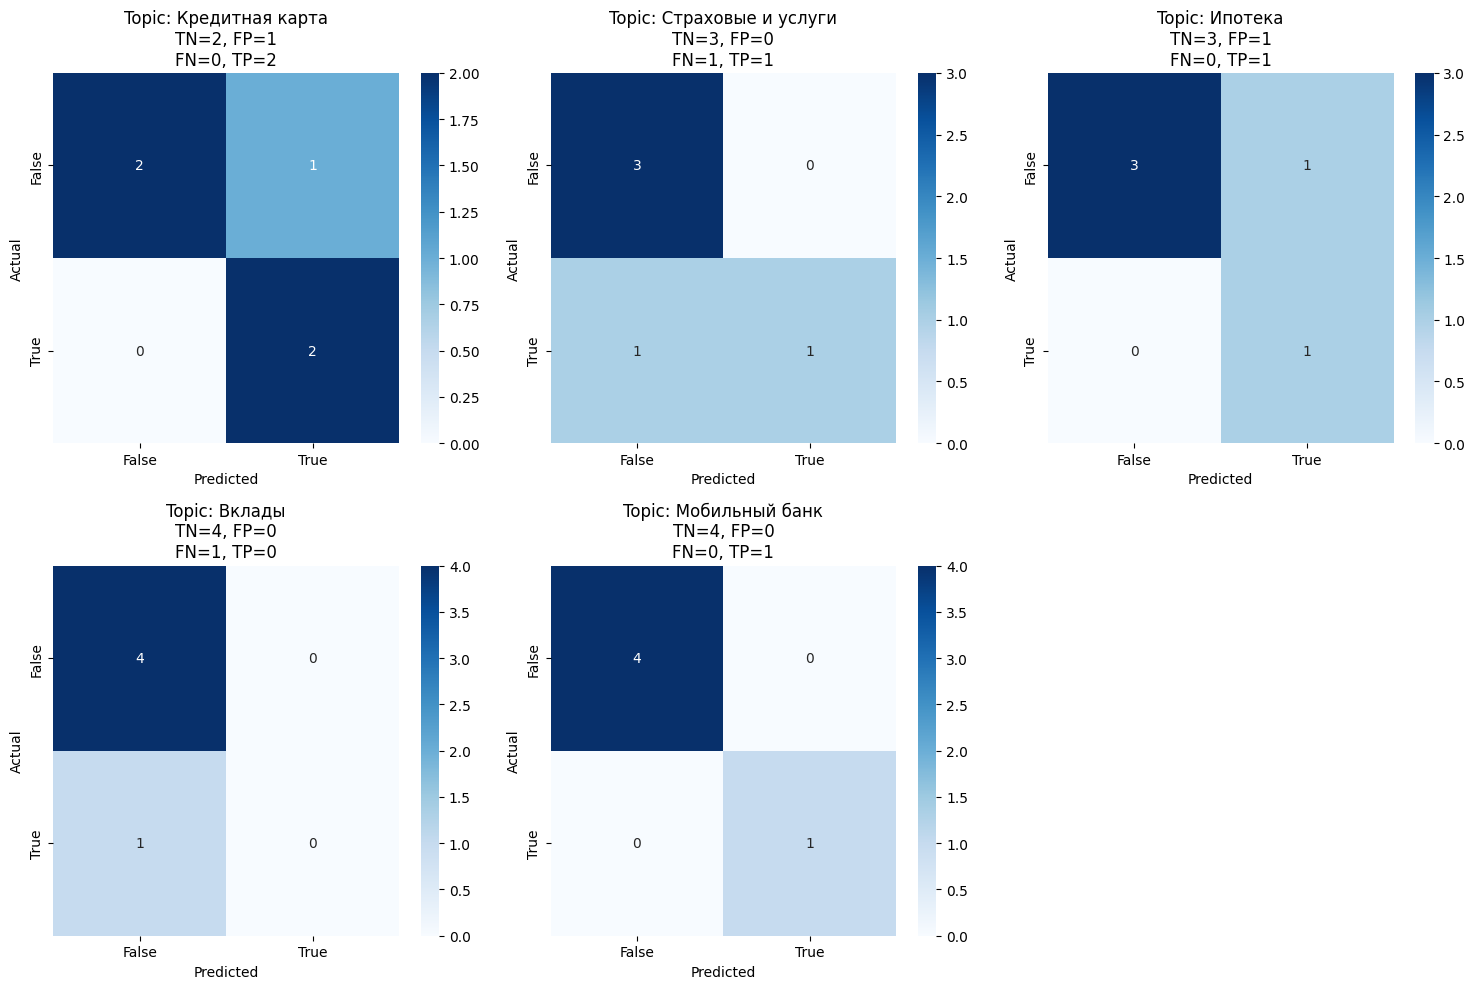


--- Корреляция предсказаний тем ---


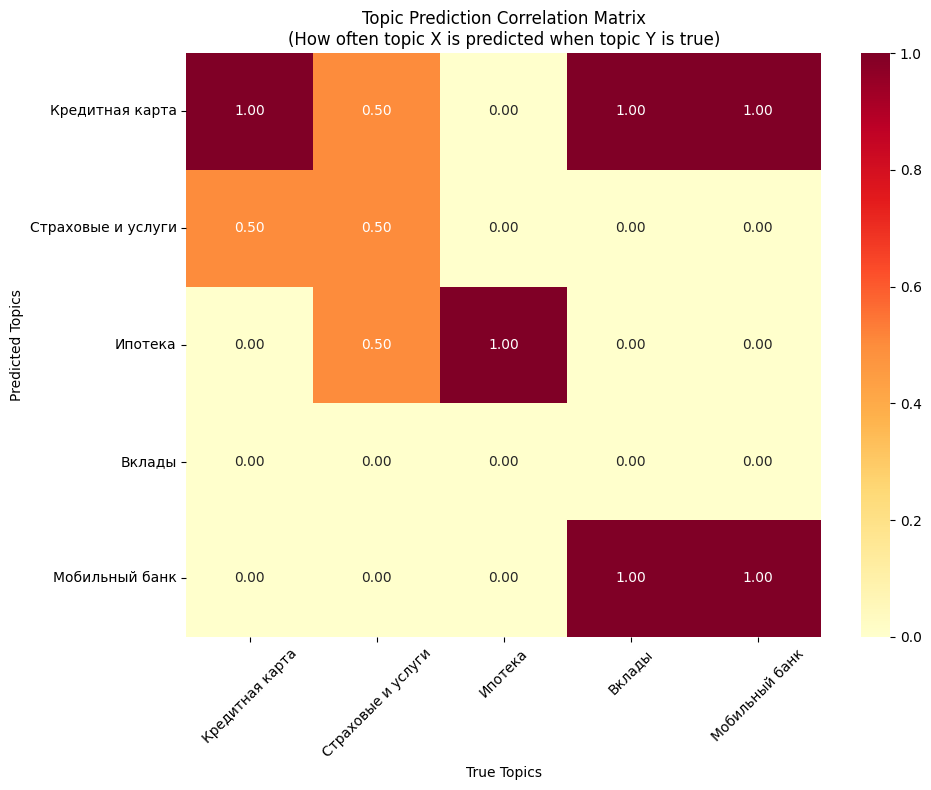


--- Метрики по каждой теме ---


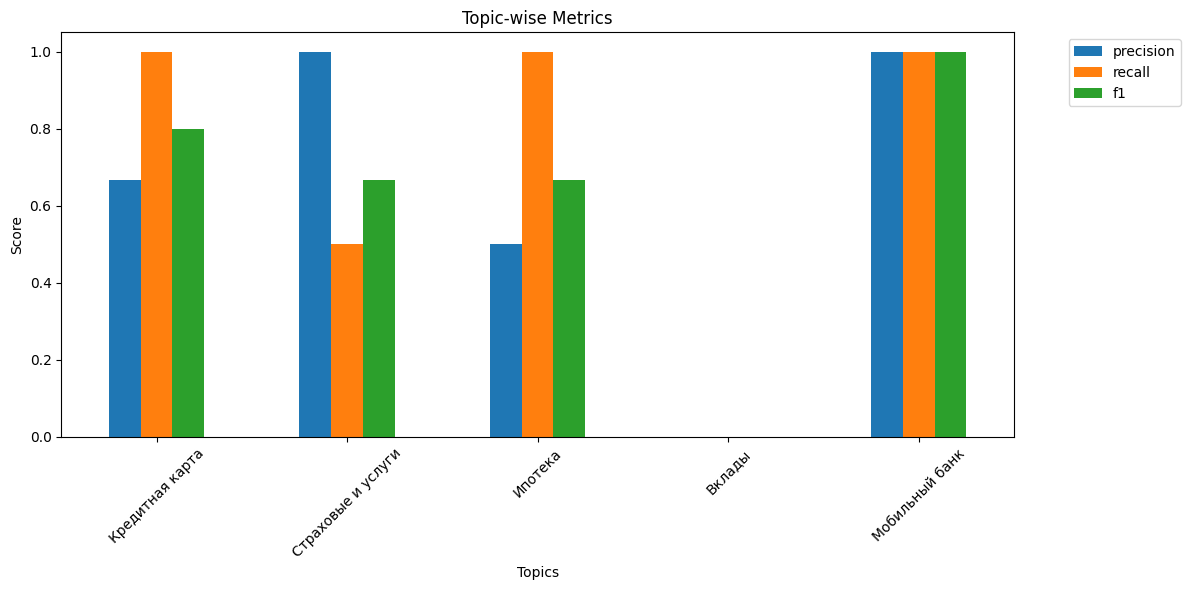


Детальный отчет по темам:
                    precision    recall  f1-score   support

   Кредитная карта       0.67      1.00      0.80         2
Страховые и услуги       1.00      0.50      0.67         2
           Ипотека       0.50      1.00      0.67         1
            Вклады       0.00      0.00      0.00         1
    Мобильный банк       1.00      1.00      1.00         1

         micro avg       0.71      0.71      0.71         7
         macro avg       0.63      0.70      0.63         7
      weighted avg       0.69      0.71      0.66         7
       samples avg       0.70      0.70      0.70         7


--- Оценка анализа тональности ---
Accuracy (только для правильных тем): 0.8000
Количество примеров для оценки: 5


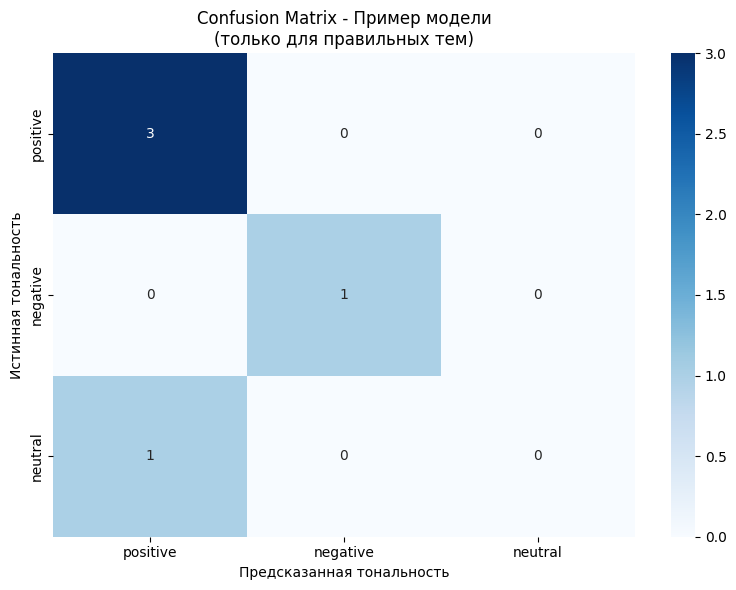


Детальный отчет по тональности:
              precision    recall  f1-score   support

    positive       1.00      1.00      1.00         1
    negative       0.00      0.00      0.00         1
     neutral       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.58      0.67      0.62         5
weighted avg       0.65      0.80      0.71         5



In [10]:
# Пример данных
all_topics = ['Кредитная карта', 'Страховые и услуги', 'Ипотека', 'Вклады', 'Мобильный банк']
all_sentiments = ['positive', 'negative', 'neutral']

# Истинные данные
true_data = [
    [{"topic": "Кредитная карта", "sentiment": "negative"}, {"topic": "Страховые и услуги", "sentiment": "neutral"}],
    [{"topic": "Ипотека", "sentiment": "positive"}],
    [{"topic": "Мобильный банк", "sentiment": "positive"}, {"topic": "Вклады", "sentiment": "negative"}],
    [{"topic": "Кредитная карта", "sentiment": "positive"}],
    [{"topic": "Страховые и услуги", "sentiment": "negative"}]
]

# Предсказания модели
pred_data = [
    [{"topic": "Кредитная карта", "sentiment": "negative"}, {"topic": "Страховые и услуги", "sentiment": "positive"}],
    [{"topic": "Ипотека", "sentiment": "positive"}],
    [{"topic": "Мобильный банк", "sentiment": "positive"}, {"topic": "Кредитная карта", "sentiment": "negative"}],
    [{"topic": "Кредитная карта", "sentiment": "positive"}],
    [{"topic": "Ипотека", "sentiment": "negative"}]  # Ошибка: предсказана не та тема
]

# Создаем оценщик и запускаем оценку
evaluator = ReviewEvaluator(all_topics, all_sentiments)
metrics = evaluator.evaluate(true_data, pred_data, "Пример модели")